In [71]:
import numpy as np
import tensorflow as tf
import cv2
import os

In [72]:
data_dir = r"C:\Users\Anurag Parasar Mund\facial emotion\dataset\train"

categories = ["angry","disgust","fear","happy","neutral","sad","surprise"]

X_train=[]
y_train=[]

for label, emotion in enumerate(categories):
    folder_path = os.path.join(data_dir, emotion)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img.mean() <5:
                continue
        
            if img.mean() > 250:
                continue
            img = img/255
            X_train.append(img)
            y_train.append(label)
        except:
            pass

X_train= np.array(X_train)
y_train= np.array(y_train)

In [73]:
print(X_train.shape)
print(y_train.shape)

(28698, 48, 48)
(28698,)


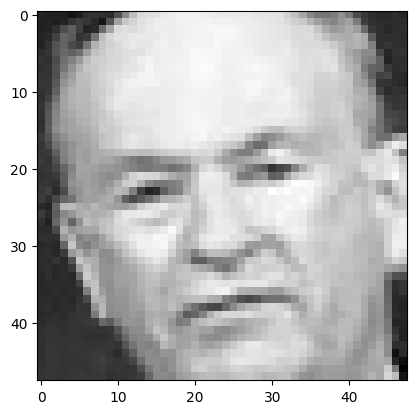

In [74]:
import matplotlib.pyplot as plt
plt.imshow(X_train[5], cmap='gray')
plt.show()

In [75]:
y_train[5]

0

In [76]:
data_dir = r"C:\Users\Anurag Parasar Mund\facial emotion\dataset\test"

categories = ["angry","disgust","fear","happy","neutral","sad","surprise"]

X_test=[]
y_test=[]

for label, emotion in enumerate(categories):
    folder_path = os.path.join(data_dir, emotion)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img.mean() <5:
                continue
        
            if img.mean() > 250:
                continue
            img = img/255
            X_test.append(img)
            y_test.append(label)
        except:
            pass

X_test= np.array(X_test)
y_test= np.array(y_test)

In [77]:
print(X_test.shape)
print(y_test.shape)

(7177, 48, 48)
(7177,)


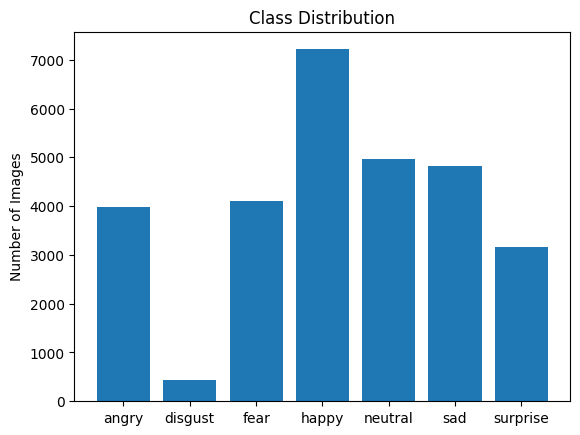

In [78]:
counts = np.bincount(y_train)

plt.bar(categories, counts)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation

In [80]:
model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), padding='same', use_bias=False, input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64, (3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64, (3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Block 3
model.add(Conv2D(128, (3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(128, (3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Dropout(0.1))

# Dense Layers
model.add(Flatten())

model.add(Dense(512, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(256, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))

In [81]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [82]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.0280126092563404, 1: 9.403014416775884, 2: 1.0006625056661669, 3: 0.5682997346429561, 4: 0.8258892598135145, 5: 0.8489779013697009, 6: 1.2932852636322667}


In [83]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import scipy
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [84]:
X_train = X_train.reshape(-1,48,48,1)
X_test = X_test.reshape(-1,48,48,1)

In [85]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)


In [86]:
history = model.fit(
   datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/100
449/449 [==============================] - 19s 38ms/step - loss: 1.7411 - accuracy: 0.3269 - val_loss: 1.9557 - val_accuracy: 0.3150 - lr: 0.0010
Epoch 2/100
449/449 [==============================] - 17s 37ms/step - loss: 1.4000 - accuracy: 0.4628 - val_loss: 1.4772 - val_accuracy: 0.4499 - lr: 0.0010
Epoch 3/100
449/449 [==============================] - 17s 37ms/step - loss: 1.2638 - accuracy: 0.5170 - val_loss: 1.2555 - val_accuracy: 0.5270 - lr: 0.0010
Epoch 4/100
449/449 [==============================] - 17s 37ms/step - loss: 1.1926 - accuracy: 0.5479 - val_loss: 1.2659 - val_accuracy: 0.5049 - lr: 0.0010
Epoch 5/100
449/449 [==============================] - 17s 37ms/step - loss: 1.1416 - accuracy: 0.5649 - val_loss: 1.1746 - val_accuracy: 0.5463 - lr: 0.0010
Epoch 6/100
449/449 [==============================] - 17s 37ms/step - loss: 1.1151 - accuracy: 0.5777 - val_loss: 1.5324 - val_accuracy: 0.4753 - lr: 0.0010
Epoch 7/100
449/449 [==============================]

In [87]:
model.save("fer_68_model.keras")

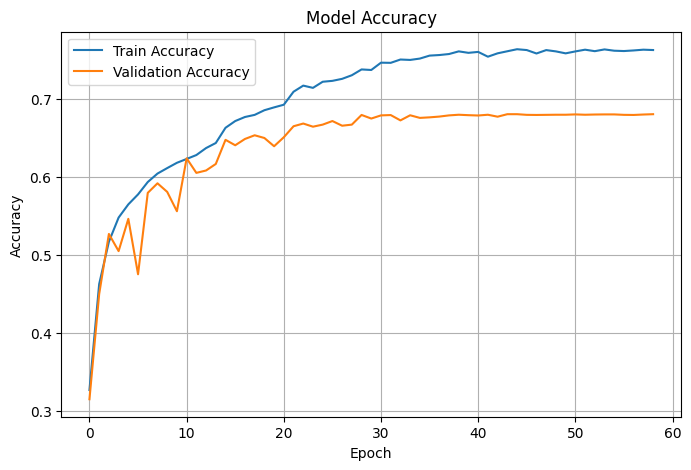

In [88]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()